# hourly energy consumption forecasting

In [1]:
import warnings, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print('device:', device)

device: mps


## load and clean the data

In [ ]:
df = pd.read_csv('hourly_energy_consumption_dataset/PJME_hourly.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])

df = df.groupby('Datetime', as_index=False)['PJME_MW'].mean()
df = df.sort_values('Datetime').reset_index(drop=True)

full = pd.date_range(df['Datetime'].min(), df['Datetime'].max(), freq='h')
df = df.set_index('Datetime').reindex(full)
gaps = int(df['PJME_MW'].isna().sum())
df['PJME_MW'] = df['PJME_MW'].interpolate('linear')
df.index.name = 'Datetime'
print('rows', len(df), ' interpolated gaps', gaps)
print('range', df.index.min(), 'to', df.index.max())
df.head()

rows 145392  interpolated gaps 30
range 2002-01-01 01:00:00 to 2018-08-03 00:00:00


,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


## eda

full series, one week, one day.

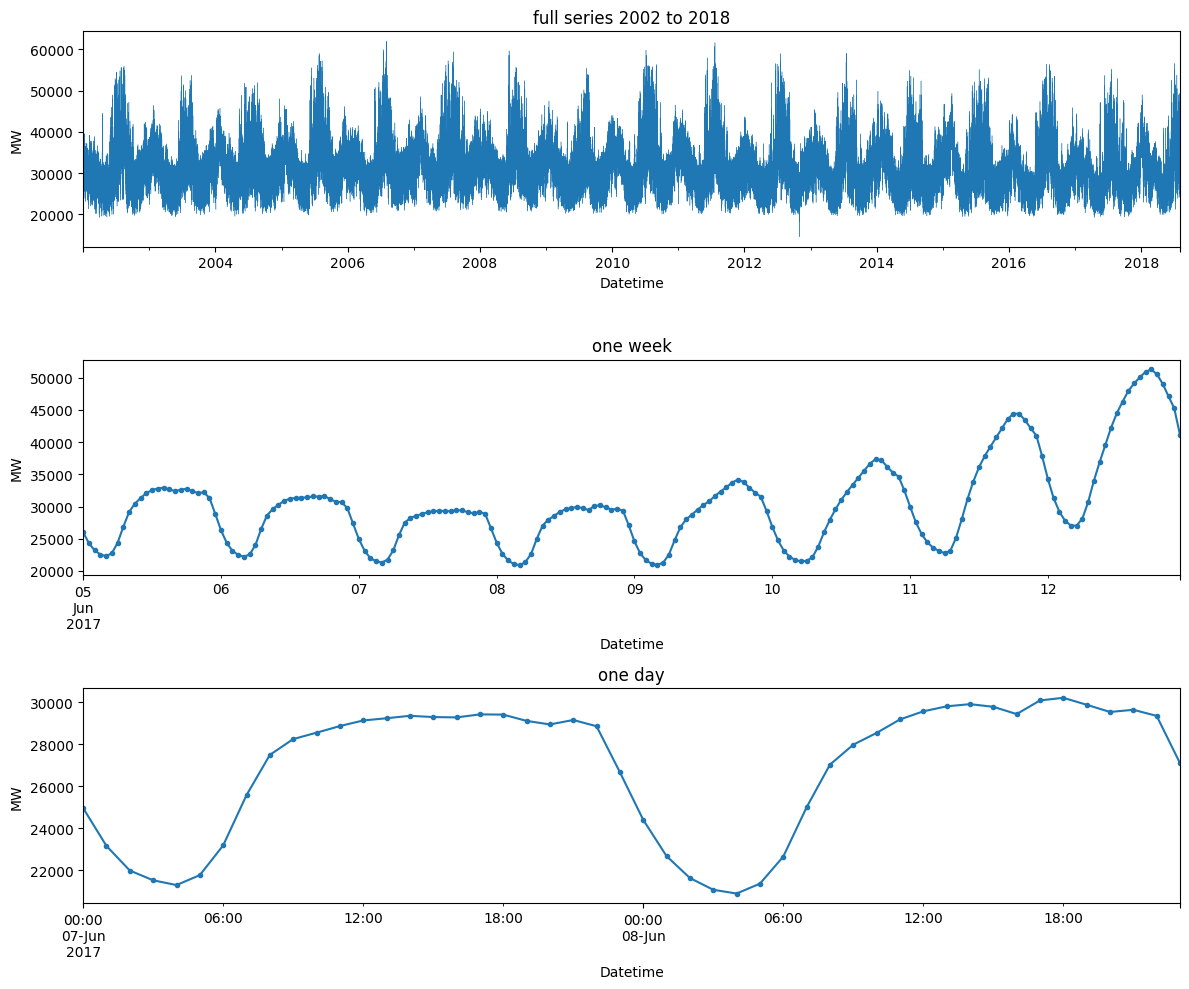

In [4]:
fig, ax = plt.subplots(3, 1, figsize=(12, 10))
df['PJME_MW'].plot(ax=ax[0], lw=0.3); ax[0].set_title('full series 2002 to 2018')
df['PJME_MW']['2017-06-05':'2017-06-12'].plot(ax=ax[1], marker='.'); ax[1].set_title('one week')
df['PJME_MW']['2017-06-07':'2017-06-08'].plot(ax=ax[2], marker='.'); ax[2].set_title('one day')
for a in ax: a.set_ylabel('MW')
plt.tight_layout(); plt.show()

## feature engineering

In [ ]:
df['hour'] = df.index.hour
df['dow'] = df.index.dayofweek
df['month'] = df.index.month
df['is_weekend'] = (df['dow'] >= 5).astype(float)

df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)
df['dow_sin']  = np.sin(2*np.pi*df['dow']/7)
df['dow_cos']  = np.cos(2*np.pi*df['dow']/7)
df['mon_sin']  = np.sin(2*np.pi*(df['month']-1)/12)
df['mon_cos']  = np.cos(2*np.pi*(df['month']-1)/12)
df.head(3)

,PJME_MW,hour,dow,month,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,mon_sin,mon_cos
Datetime,,,,,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,0.0,0.258819,0.965926,0.781831,0.62349,0.0,1.0
2002-01-01 02:00:00,29265.0,2,1,1,0.0,0.500000,0.866025,0.781831,0.62349,0.0,1.0
2002-01-01 03:00:00,28357.0,3,1,1,0.0,0.707107,0.707107,0.781831,0.62349,0.0,1.0


## chronological split

last 10 percent test, the 10 percent before that val, the rest train. no shuffling.

In [6]:
n = len(df)
n_test = int(0.1*n)
n_val  = int(0.1*n)
n_train = n - n_val - n_test

train = df.iloc[:n_train]
val   = df.iloc[n_train:n_train+n_val]
test  = df.iloc[n_train+n_val:]

for name, s in [('train', train), ('val', val), ('test', test)]:
    print(f'{name:5s}  {s.index.min()}  to  {s.index.max()}  ({len(s)} rows)')

train  2002-01-01 01:00:00  to  2015-04-09 10:00:00  (116314 rows)
val    2015-04-09 11:00:00  to  2016-12-05 05:00:00  (14539 rows)
test   2016-12-05 06:00:00  to  2018-08-03 00:00:00  (14539 rows)


## scale the target

fit the scaler on train only. fitting on the full series would leak future stats into training.

In [ ]:
scaler = StandardScaler()
scaler.fit(train[['PJME_MW']])

feat_cols = ['hour_sin','hour_cos','dow_sin','dow_cos','mon_sin','mon_cos','is_weekend']

def to_arrays(s):
    tgt = scaler.transform(s[['PJME_MW']]).ravel().astype(np.float32)
    # feature matrix is scaled target plus the calendar features
    feat = np.column_stack([tgt, s[feat_cols].values]).astype(np.float32)
    return feat, tgt

ftr, ttr = to_arrays(train)
fva, tva = to_arrays(val)
fte, tte = to_arrays(test)
N_FEAT = ftr.shape[1]
print('n features per timestep:', N_FEAT)

n features per timestep: 8


## windowing

In [8]:
IN_LEN = 168
OUT_LEN = 24

def make_windows(feat, targ, in_len=IN_LEN, out_len=OUT_LEN):
    X, y = [], []
    for i in range(len(targ) - in_len - out_len + 1):
        X.append(feat[i:i+in_len])
        y.append(targ[i+in_len:i+in_len+out_len])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

Xtr, ytr = make_windows(ftr, ttr)
Xva, yva = make_windows(fva, tva)
Xte, yte = make_windows(fte, tte)
print('train', Xtr.shape, ytr.shape)
print('val  ', Xva.shape, yva.shape)
print('test ', Xte.shape, yte.shape)

train (116123, 168, 8) (116123, 24)
val   (14348, 168, 8) (14348, 24)
test  (14348, 168, 8) (14348, 24)


## sanity check

In [ ]:
tr_idx = train.index
i = 0
x_last  = tr_idx[i + IN_LEN - 1]
y_first = tr_idx[i + IN_LEN]
y_last  = tr_idx[i + IN_LEN + OUT_LEN - 1]
print('X window spans :', tr_idx[i], 'to', x_last)
print('y window spans :', y_first, 'to', y_last)
print('gap X end to y start:', y_first - x_last)
assert y_first > x_last, 'look ahead violation: y is not after X'
print('ok, y is strictly after X')

X window spans : 2002-01-01 01:00:00 to 2002-01-08 00:00:00
y window spans : 2002-01-08 01:00:00 to 2002-01-09 00:00:00
gap X end to y start: 0 days 01:00:00
ok, y is strictly after X


## model 1: naive baseline

predict the next 24 hours as a copy of the same 24 hours one week earlier. those hours are the first day of the X window. no training

In [ ]:
def inv(a):
    return scaler.inverse_transform(np.asarray(a).reshape(-1,1)).reshape(np.asarray(a).shape)

def scores(pred, true):
    p, t = inv(pred), inv(true)
    mae = np.mean(np.abs(p - t))
    rmse = np.sqrt(np.mean((p - t)**2))
    return mae, rmse

naive_pred = Xte[:, :OUT_LEN, 0]
naive_mae, naive_rmse = scores(naive_pred, yte)
print(f'naive   MAE {naive_mae:8.1f} MW   RMSE {naive_rmse:8.1f} MW')

naive   MAE   3519.3 MW   RMSE   4787.9 MW


## model 2: lstm

In [11]:
HIDDEN = 128
LAYERS = 2
LR = 1e-3
BATCH = 128
EPOCHS = 20
PATIENCE = 4

tr_dl = DataLoader(TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr)), batch_size=BATCH, shuffle=True)
va_dl = DataLoader(TensorDataset(torch.from_numpy(Xva), torch.from_numpy(yva)), batch_size=BATCH)
te_dl = DataLoader(TensorDataset(torch.from_numpy(Xte), torch.from_numpy(yte)), batch_size=BATCH)

class LSTMNet(nn.Module):
    def __init__(self, n_feat, hidden, layers, out_len):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, layers, batch_first=True,
                            dropout=0.1 if layers > 1 else 0.0)
        self.head = nn.Linear(hidden, out_len)
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.head(h[-1])

def train_model(model, ckpt, epochs=EPOCHS, lr=LR, patience=PATIENCE):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.MSELoss()
    hist = {'tr': [], 'va': []}
    best = float('inf'); bad = 0
    for ep in range(1, epochs+1):
        model.train(); tl = 0.0; ntr = 0
        for xb, yb in tr_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward(); opt.step()
            tl += loss.item()*len(xb); ntr += len(xb)
        model.eval(); vl = 0.0; nv = 0
        with torch.no_grad():
            for xb, yb in va_dl:
                xb, yb = xb.to(device), yb.to(device)
                vl += crit(model(xb), yb).item()*len(xb); nv += len(xb)
        tl /= ntr; vl /= nv
        hist['tr'].append(tl); hist['va'].append(vl)
        if vl < best:
            best = vl; bad = 0
            torch.save(model.state_dict(), ckpt)
        else:
            bad += 1
        print(f'ep {ep:2d}  train {tl:.4f}  val {vl:.4f}')
        if bad >= patience:
            print('early stop'); break
    return hist

lstm = LSTMNet(N_FEAT, HIDDEN, LAYERS, OUT_LEN).to(device)
lstm_hist = train_model(lstm, 'energy_lstm.pt')

ep  1  train 0.1041  val 0.0863


ep  2  train 0.0719  val 0.0896


ep  3  train 0.0676  val 0.0848


ep  4  train 0.0643  val 0.0821


ep  5  train 0.0616  val 0.0846


ep  6  train 0.0589  val 0.0839


ep  7  train 0.0564  val 0.0867


ep  8  train 0.0536  val 0.0883
early stop


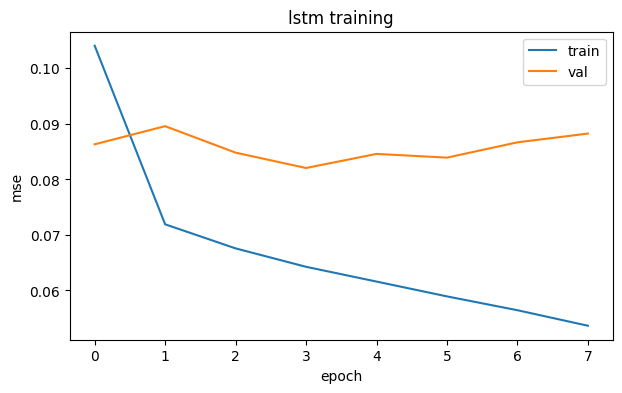

In [12]:
plt.figure(figsize=(7,4))
plt.plot(lstm_hist['tr'], label='train')
plt.plot(lstm_hist['va'], label='val')
plt.title('lstm training'); plt.xlabel('epoch'); plt.ylabel('mse'); plt.legend(); plt.show()

## evaluate lstm

lstm    MAE   1502.5 MW   RMSE   2083.8 MW


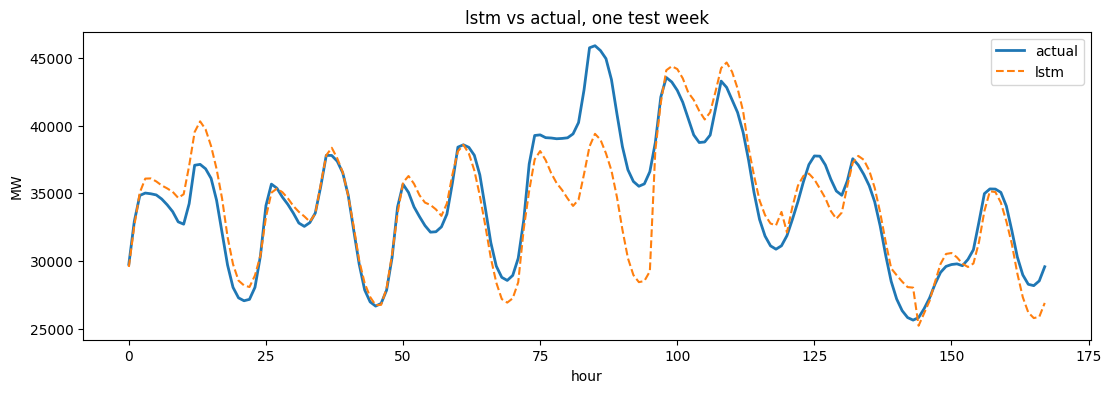

In [ ]:
def predict(model, dl):
    model.eval(); out = []
    with torch.no_grad():
        for xb, _ in dl:
            out.append(model(xb.to(device)).cpu().numpy())
    return np.concatenate(out)

lstm.load_state_dict(torch.load('energy_lstm.pt', map_location=device))
lstm_pred = predict(lstm, te_dl)
lstm_mae, lstm_rmse = scores(lstm_pred, yte)
print(f'lstm    MAE {lstm_mae:8.1f} MW   RMSE {lstm_rmse:8.1f} MW')

def week(pred, start=0):
    return np.concatenate([inv(pred[start + 24*k]) for k in range(7)])

act_week = week(yte)
plt.figure(figsize=(13,4))
plt.plot(act_week, label='actual', lw=2)
plt.plot(week(lstm_pred), label='lstm', ls='--')
plt.title('lstm vs actual, one test week'); plt.xlabel('hour'); plt.ylabel('MW'); plt.legend(); plt.show()

## model 3: transformer encoder

In [ ]:
D_MODEL = 128
NHEAD = 8
T_LAYERS = 3
T_LR = 1e-3
T_EPOCHS = 20

class PosEnc(nn.Module):
    def __init__(self, d_model, max_len=256):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos*div)
        pe[:, 1::2] = torch.cos(pos*div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class TransformerNet(nn.Module):
    def __init__(self, n_feat, d_model, nhead, layers, out_len):
        super().__init__()
        self.proj = nn.Linear(n_feat, d_model)
        self.pos = PosEnc(d_model)
        enc = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=d_model*4,
                                         dropout=0.1, batch_first=True)
        self.enc = nn.TransformerEncoder(enc, layers)
        self.head = nn.Linear(d_model, out_len)
    def forward(self, x):
        h = self.pos(self.proj(x))
        h = self.enc(h)
        h = h.mean(dim=1)
        return self.head(h)

trf = TransformerNet(N_FEAT, D_MODEL, NHEAD, T_LAYERS, OUT_LEN).to(device)
trf_hist = train_model(trf, 'energy_transformer.pt', epochs=T_EPOCHS, lr=T_LR)

ep  1  train 0.1143  val 0.0917


ep  2  train 0.0714  val 0.0806


ep  3  train 0.0665  val 0.0821


ep  4  train 0.0631  val 0.0776


ep  5  train 0.0596  val 0.0783


ep  6  train 0.0560  val 0.0813


ep  7  train 0.0522  val 0.0932


ep  8  train 0.0485  val 0.0918
early stop


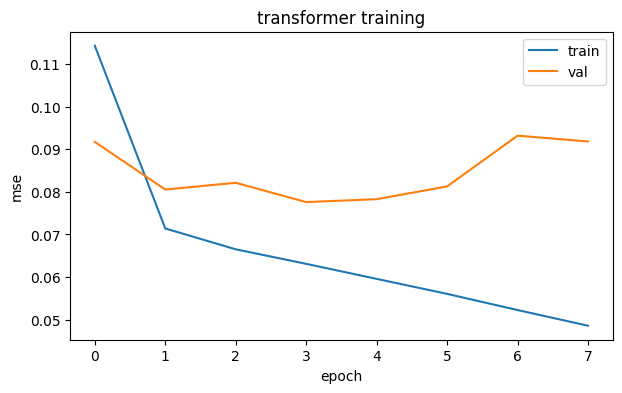

In [15]:
plt.figure(figsize=(7,4))
plt.plot(trf_hist['tr'], label='train')
plt.plot(trf_hist['va'], label='val')
plt.title('transformer training'); plt.xlabel('epoch'); plt.ylabel('mse'); plt.legend(); plt.show()

## evaluate transformer

transformer  MAE   1465.6 MW   RMSE   2049.6 MW


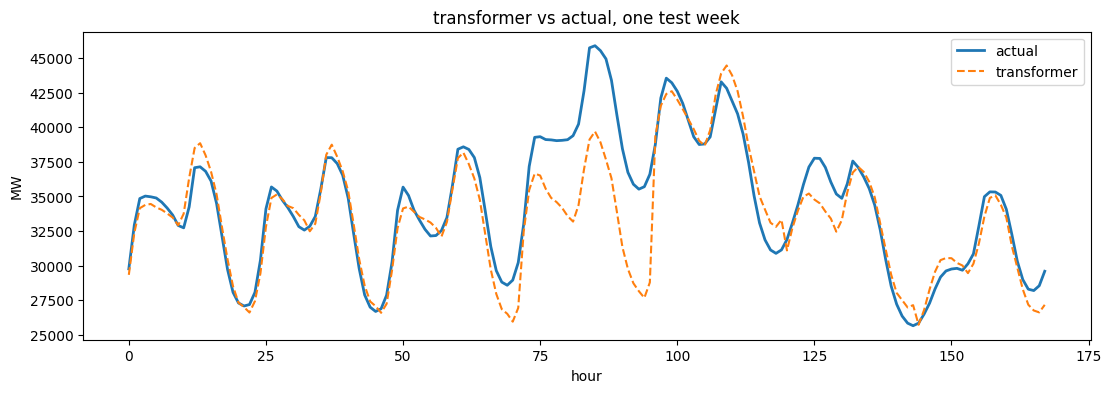

In [16]:
trf.load_state_dict(torch.load('energy_transformer.pt', map_location=device))
trf_pred = predict(trf, te_dl)
trf_mae, trf_rmse = scores(trf_pred, yte)
print(f'transformer  MAE {trf_mae:8.1f} MW   RMSE {trf_rmse:8.1f} MW')

plt.figure(figsize=(13,4))
plt.plot(act_week, label='actual', lw=2)
plt.plot(week(trf_pred), label='transformer', ls='--')
plt.title('transformer vs actual, one test week'); plt.xlabel('hour'); plt.ylabel('MW'); plt.legend(); plt.show()

## comparison

                  MAE_MW      RMSE_MW
naive        3519.300049  4787.899902
lstm         1502.500000  2083.800049
transformer  1465.599976  2049.600098


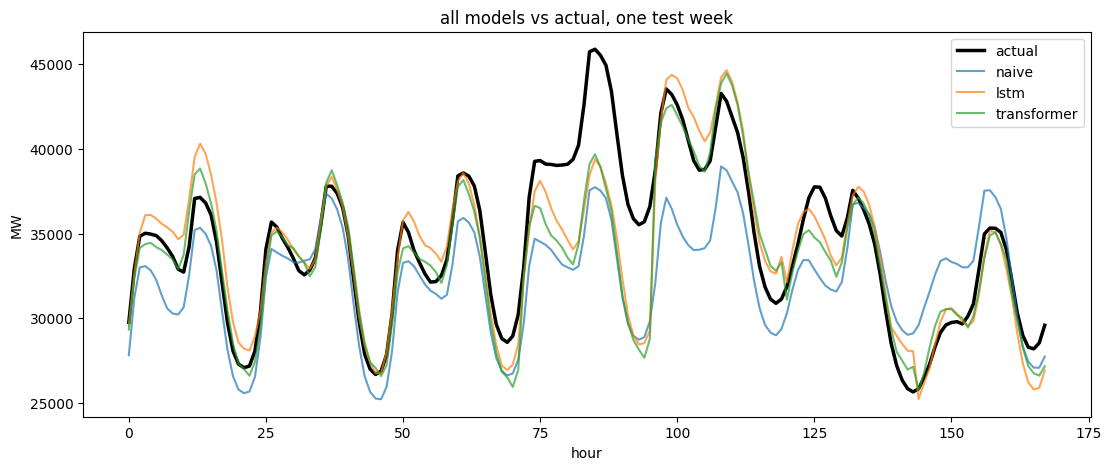

In [17]:
res = pd.DataFrame({
    'MAE_MW':  [naive_mae, lstm_mae, trf_mae],
    'RMSE_MW': [naive_rmse, lstm_rmse, trf_rmse],
}, index=['naive', 'lstm', 'transformer']).round(1)
print(res)

plt.figure(figsize=(13,5))
plt.plot(act_week, label='actual', lw=2.5, color='black')
plt.plot(week(naive_pred), label='naive', alpha=0.7)
plt.plot(week(lstm_pred), label='lstm', alpha=0.7)
plt.plot(week(trf_pred), label='transformer', alpha=0.7)
plt.title('all models vs actual, one test week'); plt.xlabel('hour'); plt.ylabel('MW')
plt.legend(); plt.show()

## honest evaluation

test set is the last 10 percent of the series, dec 2016 to aug 2018, never seen in training or scaler fitting.

| model | MAE (MW) | RMSE (MW) |
|---|---|---|
| naive | 3519 | 4788 |
| lstm | 1503 | 2084 |
| transformer | 1466 | 2050 |
